利用iris数据集中的$sepal length$，$sepal width$作为特征实现感知机算法，首先进行数据的加载与预览。

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['label'] = iris.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


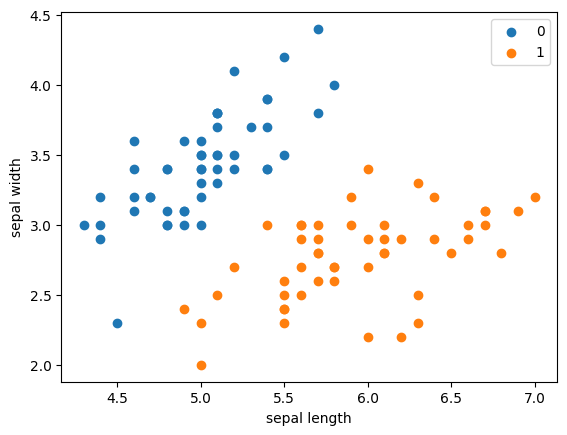

In [3]:
plt.scatter(df[:50]['sepal length (cm)'], df[:50]['sepal width (cm)'], label='0')
plt.scatter(df[50:100]['sepal length (cm)'], df[50:100]['sepal width (cm)'], label='1')
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.legend()

In [4]:
data = np.array(df.iloc[:100, [0, 1, -1]])
X, y = data[:, :-1], data[:, -1]
y = np.array([1 if i == 1 else -1 for i in y])

### **感知机学习算法的原始形式**

采取**随机梯度下降法**，感知机模型$f(x)=sign(w \cdot x + b)$，选取初值$w_0$与$b_0$，在训练集中随机抽取误分类点使梯度下降。    
$w=w+\eta y_i x_i$    
$b=b+\eta y_i$     
这种算法在直观上解释即当一个实例点被错误分类时，则调整$w$与$b$的值，使分离超平面向该误分类点进行移动。

In [ ]:
# 感知机原始形式模型
class Model_original:
    def __init__(self):
        self.w = np.ones(len(data[0]) - 1)
        self.b = 0
        self.l_rate = 0.1

    def sign(self, x, w, b):
        y = x @ w + b
        return y
    
    def fit(self, X_train, y_train):
        wrong = False
        while not wrong:
            wrong_count = 0
            for d in range(len(X_train)):
                X = X_train[d]
                y = y_train[d]
                if y * self.sign(X, self.w, self.b) <= 0:
                    self.w = self.w + self.l_rate * np.dot(y, X)
                    self.b = self.b + self.l_rate * y
                    wrong_count += 1
            if wrong_count == 0:
                wrong = True

        return "The perceptron model has been successfully built"

In [6]:
perceptron = Model_original()
perceptron.fit(X, y)

'The perceptron model has been successfully built'

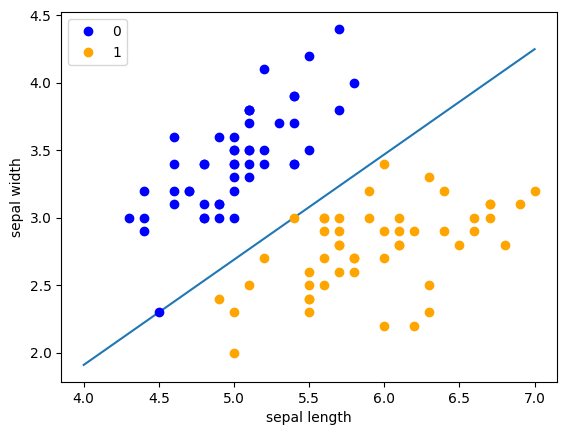

In [7]:
x_points = np.linspace(4, 7, 10)
y_ = -(perceptron.w[0] * x_points + perceptron.b) / perceptron.w[1]
plt.plot(x_points, y_)

plt.plot(data[:50, 0], data[:50, 1], 'o', color='blue', label='0')
plt.plot(data[50:100, 0], data[50:100, 1], 'o', color='orange', label='1')
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.legend()

### **感知机的学习算法的对偶形式**

同样采取**随机梯度下降法**，感知机模型$f(x)=sign(\sum_{j=1}^N a_j y_j x_j \cdot x + b)$，选取初值$\alpha = 0$与$b = 0$，在训练集中随机抽取误分类点使梯度下降。    
$\alpha_i = \alpha_i + \eta$    
$b=b+\eta y_i$     
对偶形式中训练实例仅以内积的形式出现，故可以预先将训练集中实例间的内积计算出来以矩阵形式存储，该矩阵即为$Gram$矩阵
$$G = [x_i \cdot x_j]_{N \times N}$$

In [ ]:
# 计算Gram矩阵
gram = X @ X.T

In [ ]:
# 感知机对偶形式模型
class Model_dual():
    def __init__(self):
        self.b = 0
        self.l_rate = 0.1
    
    def sign(self, alpha, y, gram_row, b):
        result = np.sum(alpha * y * gram_row) + b
        return result
    
    def fit(self, gram, y_train):
        self.alpha = np.zeros(len(y_train))
        wrong = False
        while not wrong:
            wrong_count = 0
            for d in range(len(gram)):
                gram_row = gram[d]
                y = y_train[d]
                if y * self.sign(self.alpha, y_train, gram_row, self.b) <= 0:
                    self.alpha[d] += self.l_rate
                    self.b += self.l_rate * y
                    wrong_count += 1
            if wrong_count == 0:
                wrong = True

        return "The perceptron model has been successfully built"


In [10]:
perceptron_dual = Model_dual()
perceptron_dual.fit(gram, y)

'The perceptron model has been successfully built'

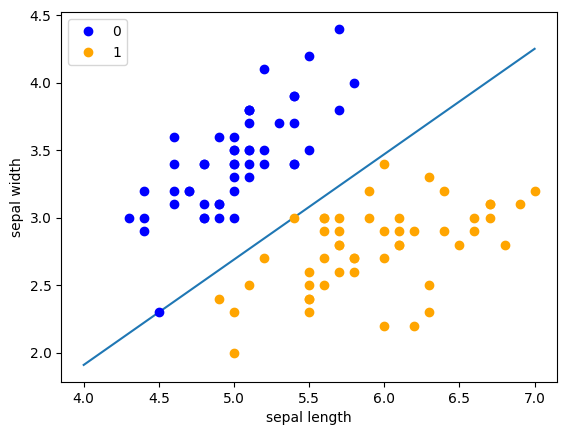

In [ ]:
x_points = np.linspace(4, 7, 10)
# 计算权重向量 w = sum(alpha_i * y_i * x_i)
w = np.sum(perceptron_dual.alpha.reshape(-1, 1) * y.reshape(-1, 1) * X, axis=0)
# 决策边界方程: w1*x + w2*y + b = 0 → y = -(w1*x + b)/w2
y_ = -(w[0] * x_points + perceptron_dual.b) / w[1]
plt.plot(x_points, y_)

plt.plot(data[:50, 0], data[:50, 1], 'o', color='blue', label='0')
plt.plot(data[50:100, 0], data[50:100, 1], 'o', color='orange', label='1')
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.legend()

当训练集线性可分时，感知机学习算法总是收敛，且存在无穷解，其解由于不同的初值与不同的迭代顺序而可能有所不同